In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [3]:

from langchain_openai import ChatOpenAI

In [4]:
llm = ChatOpenAI(model = 'gpt-4o-mini')

### both the subGraph and Graph will share the same state

In [5]:

class graphState(TypedDict):
    question : str
    answer : str
    translated_answer : str

In [6]:
def Translate(state:graphState):
    prompt = f"convert this english text {state['answer']} into the nepali text\n keep it natural and human spoken as same as that of english."
    response = llm.invoke(prompt).content
    return {'translated_answer':response}

In [7]:
subGraphBuilder = StateGraph(state_schema=graphState)
subGraphBuilder.add_node('Translate',Translate)

subGraphBuilder.add_edge(START,'Translate')


subGraph = subGraphBuilder.compile()

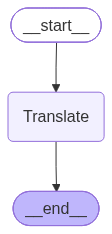

In [8]:
subGraph

In [9]:
def Generate(state:graphState):
    response = llm.invoke(state['question']).content
    return {'answer':response}

In [10]:
graphBuilder = StateGraph(state_schema=graphState)

graphBuilder.add_node('Generate',Generate)
graphBuilder.add_node('Translate_answer',subGraph)

graphBuilder.add_edge(START,'Generate')
graphBuilder.add_edge('Generate','Translate_answer')

graph = graphBuilder.compile()

In [11]:
graph.invoke(input={
    'question':'write a 500 words essay about himalayas ?'
})

{'question': 'write a 500 words essay about himalayas ?',
 'answer': 'The Himalayas, often referred to as the "abode of snow," are one of the most majestic mountain ranges in the world, stretching over 2,400 kilometers across five countries: India, Nepal, Bhutan, China, and Pakistan. This magnificent range serves not only as a natural barrier but also as a cradle for diverse ecosystems and cultures, making it one of the most intriguing geographical phenomena on Earth.\n\nGeologically, the Himalayas are relatively young, having formed approximately 50 million years ago as a result of the collision between the Indian and Eurasian tectonic plates. This tectonic activity has shaped the region\'s dramatic landscapes, characterized by towering peaks, deep valleys, and an array of geological features. The range is home to the world’s highest peak, Mount Everest (8,848 meters), along with several other towering summits such as K2, Kangchenjunga, and Lhotse. The sheer scale and elevation of the